In [22]:
import os
from pathlib import Path

def encontrar_raiz_repo(marcador=".git"):
    caminho = Path.cwd()
    for pasta in [caminho, *caminho.parents]:
        if (pasta / marcador).exists():
            return pasta
    raise FileNotFoundError(f"Não achei {marcador} subindo a partir de {caminho}")

RAIZ = encontrar_raiz_repo()
print(RAIZ)

/usr/src/myapp


In [23]:
# Processamento de dados
import numpy as np
import pandas as pd
from util import utils as ut

# Graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Modelos de aprendizado de máquina
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import adjusted_mutual_info_score

In [24]:
df_test = pd.read_csv(RAIZ / "data/processed/df_estruturada/df_test.csv", index_col=0)
df_train = pd.read_csv(RAIZ / "data/processed/df_estruturada/df_train.csv", index_col=0)
df_valid = pd.read_csv(RAIZ / "data/processed/df_estruturada/df_valid.csv", index_col=0)

## K-means

### Elbow Method

In [25]:
df_train = df_train.fillna(0)

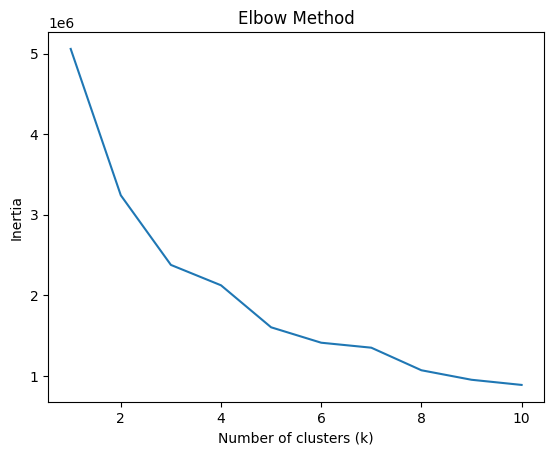

In [26]:
inertia = []
for k in range(1, 11):  # Test k from 1 to 10
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(df_train)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Silhueta

In [27]:
siluetas = []
max_clusters = 10

for n_clusters in range(2, max_clusters + 1):
    km = KMeans(n_clusters=n_clusters).fit(df_train)
    siluetas.append(silhouette_score(df_train, km.labels_))

siluetas[:5]

[0.41633645074946324,
 0.3913374899640775,
 0.404789260297186,
 0.40316742412564077,
 0.37359316557665534]

In [28]:
df_silueta = pd.DataFrame(
    {"n_clusters": list(range(2, max_clusters + 1)), "silhueta_média": siluetas}
)

df_silueta

,n_clusters,silhueta_média
0,2,0.416336
1,3,0.391337
2,4,0.404789
3,5,0.403167
4,6,0.373593
5,7,0.308002
6,8,0.339915
7,9,0.354554
8,10,0.349033


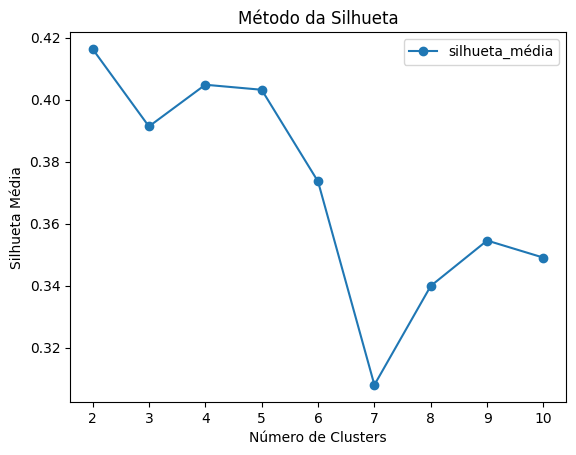

In [29]:
df_silueta.plot.line(x="n_clusters", y="silhueta_média", marker="o")
plt.title("Método da Silhueta")
plt.ylabel("Silhueta Média")
plt.xlabel("Número de Clusters")
plt.show()

### Plot

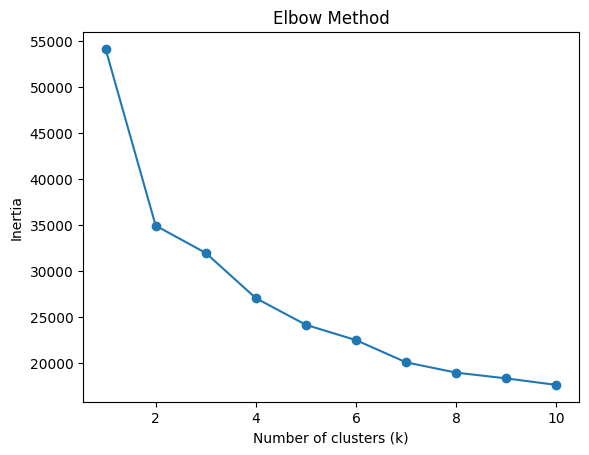

In [30]:
X = StandardScaler().fit_transform(df_train)

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Visualização com PCA

In [31]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init="auto"
)

df_train["cluster"] = kmeans.fit_predict(X)

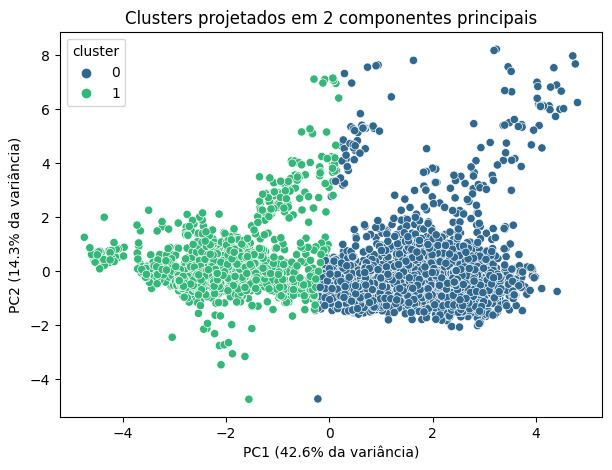

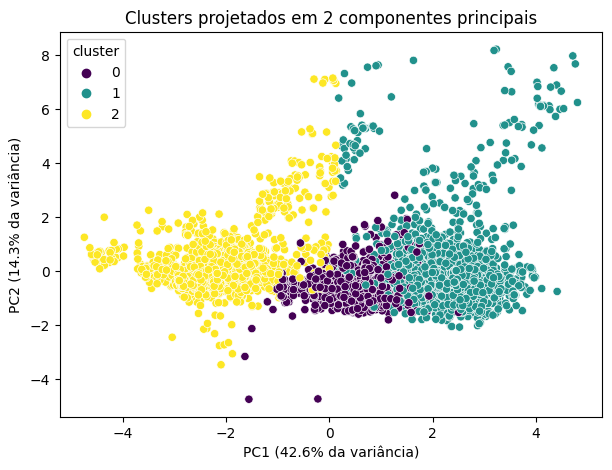

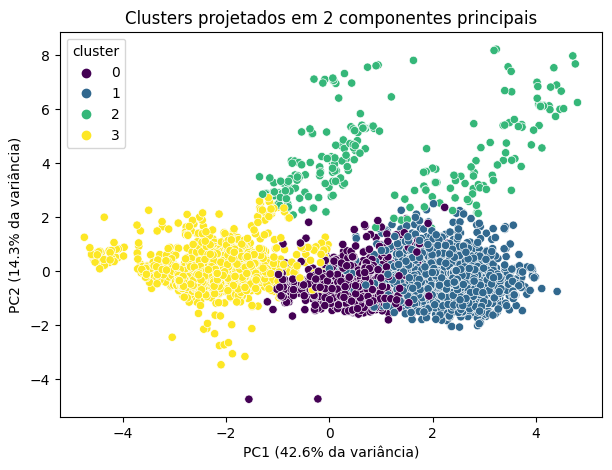

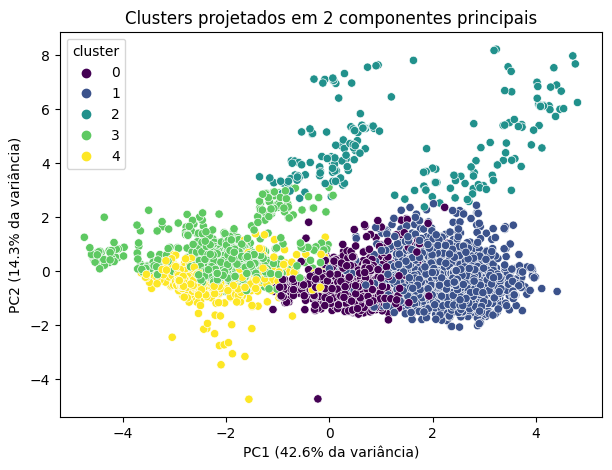

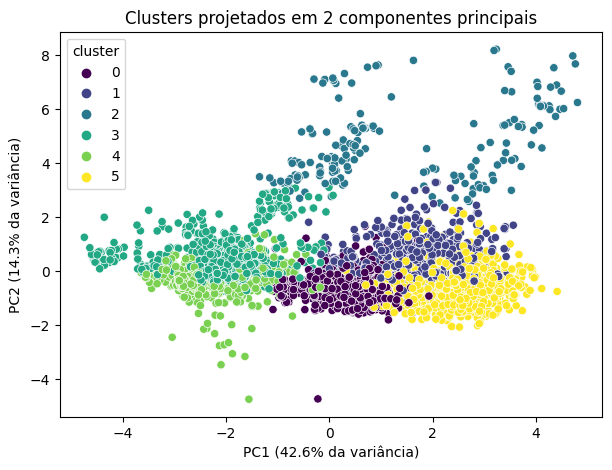

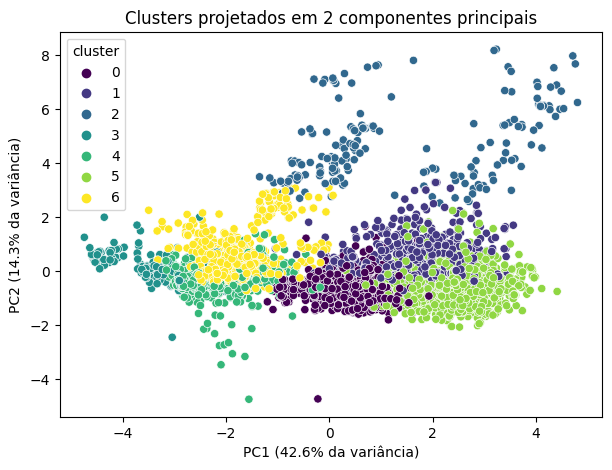

In [36]:
for i in range(2,8):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init="auto"
    )

    df_train["cluster"] = kmeans.fit_predict(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)  # X aqui é o StandardScaler já aplicado

    plt.figure(figsize=(7,5))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_train["cluster"], palette="viridis")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} da variância)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} da variância)")
    plt.title("Clusters projetados em 2 componentes principais")
    plt.show()

In [33]:
def calcular_metricas(x: str, y: str, target: str, df: pd.DataFrame) -> None:
    """
    Função para calcular métricas de avaliação de clustering.
        Parametros:
            x: str -> coluna que representa a primeira dimensão dos dados
            y: str -> coluna que representa a segunda dimensão dos dados
            target: str -> coluna que representa os rótulos dos clusters
            df: pd.DataFrame -> DataFrame contendo os dados
        Retorna:
            None -> apenas imprime as métricas calculadas
    """
    print(f"Calculando métricas para o target: {target}\n")
    # Calcula a métrica de Silhouette
    ss = round(silhouette_score(df[[x, y]], df[target]), 3)
    print(f"Silhouette Score -> {ss}")

    # Calcula a métrica de Calinski-Harabasz
    chs = round(calinski_harabasz_score(df[[x, y]], df[target]), 3)
    print(f"Calinski Harabasz Score -> {chs}")

    # Calcula a métrica de Davies-Bouldin
    dbs = round(davies_bouldin_score(df[[x, y]], df[target]), 3)
    print(f"Davies Bouldin Score -> {dbs}")
    return None

In [34]:
df_train["x_pca"] = X_pca[:,0]
df_train["y_pca"] = X_pca[:,1]

In [35]:
calcular_metricas('y_pca', 'x_pca', 'cluster', df_train)

Calculando métricas para o target: cluster

Silhouette Score -> 0.223
Calinski Harabasz Score -> 4776.143
Davies Bouldin Score -> 1.211
